# ECM-402 — AI for Signal Processing | Lab 1B

## Problem 4

This notebook is a standalone, dependency-aware extraction from `ECM402_Lab1B_Solution.ipynb`. Only prerequisite code required for this problem is retained.


Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks

np.random.seed(0)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True

ECG Generation / Loading

In [2]:
# ============================================================
# ECG Generation / Loading
# Required prerequisite for Problem 4
# ============================================================

def synthetic_ecg_beat(t, t0, amp_scale=1.0):
    """
    Generate one synthetic PQRST ECG complex.
    """

    def g(mu, sigma, A):
        return A * np.exp(
            -((t - mu) ** 2) / (2 * sigma ** 2)
        )

    p = g(t0 - 0.20, 0.025, 0.15)
    q = g(t0 - 0.05, 0.008, -0.15)
    r = g(t0, 0.008, 1.20)
    s = g(t0 + 0.05, 0.010, -0.25)
    t_wave = g(t0 + 0.30, 0.040, 0.35)

    return amp_scale * (
        p + q + r + s + t_wave
    )


def synthetic_ecg(
    duration=10.0,
    fs=360,
    hr_bpm=75,
    seed=0
):
    """
    Generate a synthetic ECG signal with
    small heart-rate variability and measurement noise.
    """

    rng = np.random.default_rng(seed)

    n = int(duration * fs)

    t = np.arange(n) / fs

    rr = 60.0 / hr_bpm

    beat_times = np.arange(
        0.3,
        duration,
        rr
    )

    beat_times = (
        beat_times
        + rng.normal(
            0,
            0.01,
            size=beat_times.shape
        )
    )

    s = np.zeros(n)

    for bt in beat_times:
        s += synthetic_ecg_beat(
            t,
            bt
        )

    s += rng.normal(
        0,
        0.008,
        size=n
    )

    return s, t, fs, beat_times


def load_ecg(
    record="100",
    duration=10.0,
    seed=0
):
    """
    Try to load a real MIT-BIH record.
    If unavailable, use synthetic ECG.
    """

    try:
        import wfdb

        rec = wfdb.rdrecord(
            record,
            pn_dir="mitdb"
        )

        fs = rec.fs

        n = int(
            duration * fs
        )

        s = rec.p_signal[
            :n,
            0
        ].astype(float)

        s = s - np.median(s)

        t = np.arange(n) / fs

        print(
            f"Loaded REAL MIT-BIH record "
            f"{record} from PhysioNet "
            f"(fs={fs} Hz)."
        )

        return (
            s,
            t,
            fs,
            "real"
        )

    except Exception as e:

        s, t, fs, _ = synthetic_ecg(
            duration=duration,
            fs=360,
            hr_bpm=75,
            seed=seed
        )

        print(
            f"[Fallback] Could not reach PhysioNet "
            f"({type(e).__name__}: {e})."
        )

        print(
            "Using synthetic ECG instead "
            "(fs=360 Hz, ~75 bpm)."
        )

        return (
            s,
            t,
            fs,
            "synthetic"
        )


s_clean, t, fs, source = load_ecg(
    "100",
    duration=10.0,
    seed=0
)

print(
    f"Segment length: {len(s_clean)} samples "
    f"({len(s_clean) / fs:.2f} s), "
    f"source = {source}"
)

[Fallback] Could not reach PhysioNet (ModuleNotFoundError: No module named 'wfdb').
Using synthetic ECG instead (fs=360 Hz, ~75 bpm).
Segment length: 3600 samples (10.00 s), source = synthetic


Baseline Wander and Corrupted ECG

In [3]:
# ============================================================
# Baseline Wander and Corrupted ECG
# Required prerequisite
# ============================================================

A1, A2 = 0.15, 0.10

f1, f2 = 0.2, 0.4

phi1, phi2 = 0.0, np.pi / 3


b_true = (
    A1 * np.sin(
        2 * np.pi * f1 * t + phi1
    )
    +
    A2 * np.sin(
        2 * np.pi * f2 * t + phi2
    )
)

x = s_clean + b_true

R-Peak Detection and TP Anchor Extraction

In [4]:
# ============================================================
# R-Peak Detection and TP-Segment Anchor Extraction
# Required prerequisite
# ============================================================

def detect_r_peaks(sig, fs):
    """
    Detect R-peaks using scipy.signal.find_peaks.
    """

    min_distance = int(
        0.4 * fs
    )

    height = np.percentile(
        sig,
        85
    )

    peaks, _ = find_peaks(
        sig,
        height=height,
        distance=min_distance
    )

    return peaks


def extract_anchor_points(
    sig,
    t,
    r_peaks,
    frac_start=0.45,
    frac_end=0.85,
    subsample=3
):
    """
    Extract TP-segment samples between
    consecutive R-peaks.
    """

    anchors_t = []
    anchors_y = []

    for i in range(
        len(r_peaks) - 1
    ):

        rr_samples = (
            r_peaks[i + 1]
            - r_peaks[i]
        )

        start = (
            r_peaks[i]
            + int(
                frac_start
                * rr_samples
            )
        )

        end = (
            r_peaks[i]
            + int(
                frac_end
                * rr_samples
            )
        )

        idx = np.arange(
            start,
            end,
            subsample
        )

        idx = idx[
            (idx >= 0)
            &
            (idx < len(sig))
        ]

        anchors_t.extend(
            t[idx]
        )

        anchors_y.extend(
            sig[idx]
        )

    return (
        np.array(anchors_t),
        np.array(anchors_y)
    )


r_peaks = detect_r_peaks(
    x,
    fs
)

t_anchor, y_anchor = (
    extract_anchor_points(
        x,
        t,
        r_peaks
    )
)

print(
    f"Detected {len(r_peaks)} R-peaks "
    f"-> {len(t_anchor)} TP anchor points."
)

Detected 13 R-peaks -> 465 TP anchor points.


Evaluation Functions

In [5]:
# ============================================================
# Evaluation Metrics
# ============================================================

def mse(a, b):
    """
    Mean Squared Error.
    """
    return np.mean(
        (a - b) ** 2
    )


def snr_db(signal, error):
    """
    Signal-to-Noise Ratio in dB.
    """
    return 10 * np.log10(
        np.sum(signal ** 2)
        /
        np.sum(error ** 2)
    )


def evaluate(
    b_true,
    b_hat,
    s_true,
    s_hat
):
    """
    Evaluate baseline estimation and
    corrected ECG quality.
    """

    return {
        "MSE(b, b_hat)": mse(
            b_true,
            b_hat
        ),

        "BSNR (dB)": snr_db(
            b_true,
            b_true - b_hat
        ),

        "Output SNR (dB)": snr_db(
            s_true,
            s_true - s_hat
        )
    }

Moving-Average Baseline

In [6]:
# ============================================================
# Problem 1 Dependency
# Moving-Average Baseline Estimation
# ============================================================

def moving_average_baseline(
    sig,
    fs,
    window_sec=0.6
):
    """
    Estimate ECG baseline using a moving-average filter.
    """

    win = int(
        window_sec * fs
    )

    if win % 2 == 0:
        win += 1

    kernel = np.ones(win) / win

    return np.convolve(
        sig,
        kernel,
        mode="same"
    )


b_hat_mavg = moving_average_baseline(
    x,
    fs,
    window_sec=0.6
)

s_hat_mavg = (
    x - b_hat_mavg
)

Polynomial Regression Utilities

In [7]:
# ============================================================
# Problem 2 Dependency
# Polynomial Regression Utilities
# ============================================================

def normalize_time(
    t_query,
    t_min,
    t_max
):
    """
    Normalize time to [-1, 1].
    """

    return (
        2
        * (t_query - t_min)
        / (t_max - t_min)
        - 1
    )


def vandermonde(
    t_norm,
    degree
):
    """
    Construct polynomial design matrix.
    """

    return np.vstack(
        [
            t_norm ** k
            for k in range(
                degree + 1
            )
        ]
    ).T


def fit_polynomial(
    t_anchor_norm,
    y_anchor,
    degree
):
    """
    Fit polynomial regression using least squares.
    """

    Phi = vandermonde(
        t_anchor_norm,
        degree
    )

    w = np.linalg.solve(
        Phi.T @ Phi,
        Phi.T @ y_anchor
    )

    return w


def predict_polynomial(
    t_query_norm,
    w
):
    """
    Evaluate a fitted polynomial.
    """

    degree = len(w) - 1

    Phi = vandermonde(
        t_query_norm,
        degree
    )

    return Phi @ w

Problem 2 Dependency: Select p_star

In [8]:
# ============================================================
# Problem 2 Dependency
# Select Best Global Polynomial Degree
# ============================================================

t_min = t.min()
t_max = t.max()

t_anchor_n = normalize_time(
    t_anchor,
    t_min,
    t_max
)

t_full_n = normalize_time(
    t,
    t_min,
    t_max
)


degrees = [
    1,
    3,
    5,
    9,
    15,
    25
]


split_idx = int(
    0.7 * len(t_anchor_n)
)

order = np.argsort(
    t_anchor_n
)

train_idx = order[
    :split_idx
]

val_idx = order[
    split_idx:
]


val_mse_curve = []


for p in degrees:

    w = fit_polynomial(
        t_anchor_n[train_idx],
        y_anchor[train_idx],
        p
    )

    y_val_hat = predict_polynomial(
        t_anchor_n[val_idx],
        w
    )

    val_mse_curve.append(
        mse(
            y_anchor[val_idx],
            y_val_hat
        )
    )


p_star = degrees[
    int(
        np.argmin(
            val_mse_curve
        )
    )
]


print(
    "Validation MSE per polynomial degree:"
)

for p, value in zip(
    degrees,
    val_mse_curve
):

    marker = (
        "  <-- selected"
        if p == p_star
        else ""
    )

    print(
        f"degree={p:2d}: "
        f"validation MSE={value:.5f}"
        f"{marker}"
    )


print(
    f"\nSelected polynomial degree "
    f"p* = {p_star}"
)

Validation MSE per polynomial degree:
degree= 1: validation MSE=0.02321  <-- selected
degree= 3: validation MSE=0.06088
degree= 5: validation MSE=5.34007
degree= 9: validation MSE=111855.84141
degree=15: validation MSE=1304090178.39690
degree=25: validation MSE=1226170336748.17432

Selected polynomial degree p* = 1


Ridge Regression

In [9]:
# ============================================================
# Problem 3 Dependency
# Ridge Regression
# ============================================================

p_fixed = 25

Phi_anchor = vandermonde(
    t_anchor_n,
    p_fixed
)

Phi_full = vandermonde(
    t_full_n,
    p_fixed
)


def fit_ridge(
    Phi,
    y,
    lam
):
    """
    Fit Ridge regression.

    The intercept coefficient is not regularized.
    """

    D = np.eye(
        Phi.shape[1]
    )

    D[0, 0] = 0.0

    w = np.linalg.solve(
        Phi.T @ Phi
        + lam * D,
        Phi.T @ y
    )

    return w


lambdas = np.logspace(
    -4,
    4,
    20
)


ridge_results = {}


for lam in lambdas:

    w = fit_ridge(
        Phi_anchor,
        y_anchor,
        lam
    )

    b_hat = Phi_full @ w

    s_hat = (
        x - b_hat
    )

    ridge_results[lam] = {
        "w": w,
        "b_hat": b_hat,
        "s_hat": s_hat,
        "metrics": evaluate(
            b_true,
            b_hat,
            s_clean,
            s_hat
        )
    }


ridge_snr = [
    ridge_results[lam]["metrics"]
    ["Output SNR (dB)"]
    for lam in lambdas
]


lam_star_ridge = lambdas[
    int(
        np.argmax(
            ridge_snr
        )
    )
]


best_ridge = ridge_results[
    lam_star_ridge
]


b_hat_ridge_best = (
    Phi_full
    @ best_ridge["w"]
)


print(
    f"Selected Ridge lambda* = "
    f"{lam_star_ridge:.4g}"
)

Selected Ridge lambda* = 0.2336


Local Polynomial Regression

In [10]:
# ============================================================
# Problem 4(a)
# Local Polynomial Baseline Estimation
# ============================================================

def local_polynomial_baseline(
    t_query,
    t_anchor,
    y_anchor,
    fs,
    window_sec=2.0,
    overlap=0.5,
    degree=3
):
    """
    Estimate baseline using overlapping local
    polynomial regression windows.

    Parameters
    ----------
    t_query : ndarray
        Time points where the baseline is estimated.

    t_anchor : ndarray
        TP-segment anchor time points.

    y_anchor : ndarray
        Anchor amplitudes.

    fs : float
        Sampling frequency.

    window_sec : float
        Local regression window duration.

    overlap : float
        Fractional overlap between consecutive windows.

    degree : int
        Local polynomial degree.
    """

    step = (
        window_sec
        * (1 - overlap)
    )

    starts = np.arange(
        t_query.min(),
        t_query.max()
        - window_sec
        + step,
        step
    )

    b_hat = np.zeros_like(
        t_query
    )

    weight_sum = np.zeros_like(
        t_query
    )


    for w_start in starts:

        w_end = (
            w_start
            + window_sec
        )

        center = (
            0.5
            * (w_start + w_end)
        )


        # Anchor points inside the local window
        mask_anchor = (
            (t_anchor >= w_start)
            &
            (t_anchor < w_end)
        )


        # Skip windows with insufficient data
        if (
            mask_anchor.sum()
            < degree + 1
        ):
            continue


        t_loc = (
            t_anchor[
                mask_anchor
            ]
        )

        y_loc = (
            y_anchor[
                mask_anchor
            ]
        )


        # Normalize local time
        t_loc_n = normalize_time(
            t_loc,
            w_start,
            w_end
        )


        # Fit local polynomial
        w_coef = fit_polynomial(
            t_loc_n,
            y_loc,
            degree
        )


        # Query points inside local window
        mask_query = (
            (t_query >= w_start)
            &
            (t_query < w_end)
        )


        t_q_n = normalize_time(
            t_query[
                mask_query
            ],
            w_start,
            w_end
        )


        local_pred = (
            predict_polynomial(
                t_q_n,
                w_coef
            )
        )


        # Triangular blending weight
        tri_weight = (
            1
            -
            np.abs(
                t_query[
                    mask_query
                ]
                - center
            )
            /
            (window_sec / 2)
        )


        tri_weight = np.clip(
            tri_weight,
            1e-3,
            1
        )


        # Weighted overlap-add
        b_hat[
            mask_query
        ] += (
            local_pred
            * tri_weight
        )

        weight_sum[
            mask_query
        ] += tri_weight


    weight_sum[
        weight_sum == 0
    ] = 1.0


    return (
        b_hat
        / weight_sum
    )

Local Polynomial Model

In [11]:
# ============================================================
# Problem 4(a)
# Apply Local Polynomial Regression
# ============================================================

b_hat_local = (
    local_polynomial_baseline(
        t,
        t_anchor,
        y_anchor,
        fs,
        window_sec=2.0,
        overlap=0.5,
        degree=3
    )
)


s_hat_local = (
    x - b_hat_local
)


metrics_local = evaluate(
    b_true,
    b_hat_local,
    s_clean,
    s_hat_local
)


print(
    "Local Polynomial Regression "
    "Evaluation:"
)

for key, value in (
    metrics_local.items()
):

    print(
        f"{key:20s}: "
        f"{value:.4f}"
    )

Local Polynomial Regression Evaluation:
MSE(b, b_hat)       : 0.0040
BSNR (dB)           : 6.0611
Output SNR (dB)     : 9.9817


Compare All Methods

In [12]:
# ============================================================
# Problem 4(b)
# Comparison of Classical, Global, Ridge and Local Methods
# ============================================================

# Global polynomial using selected p*
w_global = fit_polynomial(
    t_anchor_n,
    y_anchor,
    p_star
)

b_hat_global = (
    predict_polynomial(
        t_full_n,
        w_global
    )
)

s_hat_global = (
    x - b_hat_global
)


# Best Ridge correction
s_hat_ridge = (
    x - b_hat_ridge_best
)


methods = {
    "Moving-average (P1)": (
        b_hat_mavg,
        s_hat_mavg
    ),

    f"Global polynomial p*={p_star} (P2)": (
        b_hat_global,
        s_hat_global
    ),

    f"Ridge (P3), lambda={lam_star_ridge:.3g}": (
        b_hat_ridge_best,
        s_hat_ridge
    ),

    "Local polynomial (P4)": (
        b_hat_local,
        s_hat_local
    )
}


rows = []


for name, (
    b_hat_method,
    s_hat_method
) in methods.items():

    metrics = evaluate(
        b_true,
        b_hat_method,
        s_clean,
        s_hat_method
    )

    rows.append({
        "Method": name,
        **metrics
    })


comparison_table = pd.DataFrame(
    rows
)


print(
    comparison_table.to_string(
        index=False
    )
)

                     Method  MSE(b, b_hat)  BSNR (dB)  Output SNR (dB)
        Moving-average (P1)       0.005653   4.585508         8.506119
Global polynomial p*=1 (P2)       0.015210   0.287328         4.207938
   Ridge (P3), lambda=0.234       0.008810   2.658868         6.579478
      Local polynomial (P4)       0.004025   6.061087         9.981698


Corrected ECG Comparison

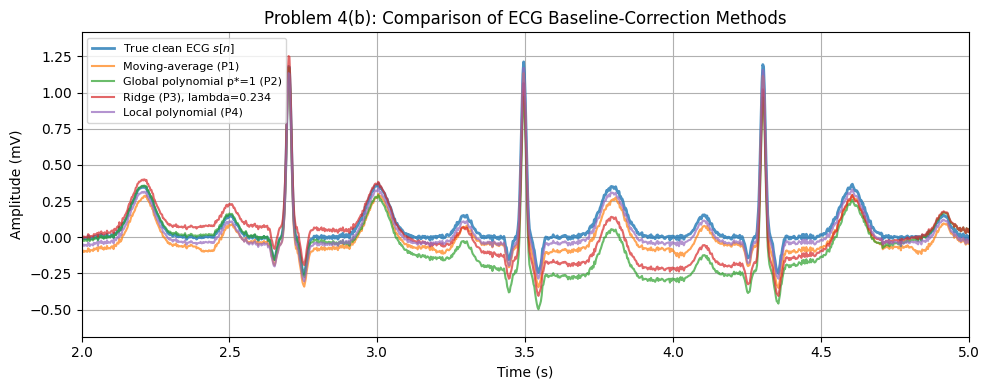

In [13]:
# ============================================================
# Problem 4(b)
# Corrected ECG Comparison
# ============================================================

plt.figure(
    figsize=(10, 4)
)


plt.plot(
    t,
    s_clean,
    label="True clean ECG $s[n]$",
    linewidth=2,
    alpha=0.8
)


for name, (
    _,
    s_hat_method
) in methods.items():

    plt.plot(
        t,
        s_hat_method,
        alpha=0.7,
        label=name
    )


# Zoom into representative ECG cycles
plt.xlim(
    2,
    5
)


plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Amplitude (mV)"
)

plt.title(
    "Problem 4(b): Comparison of ECG "
    "Baseline-Correction Methods"
)

plt.legend(
    fontsize=8
)

plt.tight_layout()

plt.show()

Longer/Faster Baseline Drift

In [14]:
# ============================================================
# Problem 4(c)
# Longer Segment with Faster Baseline Drift
# ============================================================

s_long, t_long, _, _ = synthetic_ecg(
    duration=30.0,
    fs=fs,
    hr_bpm=75,
    seed=1
)


# Faster baseline drift
b_long = (
    0.15
    * np.sin(
        2 * np.pi * 0.5 * t_long
    )
    +
    0.10
    * np.sin(
        2 * np.pi * 0.9 * t_long
        + 1.0
    )
)


x_long = (
    s_long
    + b_long
)


# Detect R-peaks
r_peaks_long = (
    detect_r_peaks(
        x_long,
        fs
    )
)


# Extract TP anchors
(
    t_anchor_long,
    y_anchor_long
) = extract_anchor_points(
    x_long,
    t_long,
    r_peaks_long
)


print(
    f"Long segment: "
    f"{len(s_long)} samples"
)

print(
    f"Detected "
    f"{len(r_peaks_long)} R-peaks"
)

print(
    f"Extracted "
    f"{len(t_anchor_long)} anchor points"
)

Long segment: 10800 samples
Detected 38 R-peaks
Extracted 1428 anchor points


Global vs Local Polynomial

In [15]:
# ============================================================
# Problem 4(c)
# Global Polynomial vs Local Polynomial
# ============================================================

# Normalize long-segment time
t_long_n_full = normalize_time(
    t_long,
    t_long.min(),
    t_long.max()
)

t_long_n_anchor = normalize_time(
    t_anchor_long,
    t_long.min(),
    t_long.max()
)


# Global polynomial
w_global_long = fit_polynomial(
    t_long_n_anchor,
    y_anchor_long,
    p_star
)


b_hat_global_long = (
    predict_polynomial(
        t_long_n_full,
        w_global_long
    )
)


# Local polynomial
b_hat_local_long = (
    local_polynomial_baseline(
        t_long,
        t_anchor_long,
        y_anchor_long,
        fs,
        window_sec=2.0,
        overlap=0.5,
        degree=3
    )
)


# Corrected ECG signals
s_hat_global_long = (
    x_long
    - b_hat_global_long
)

s_hat_local_long = (
    x_long
    - b_hat_local_long
)


# Output SNR
snr_global_long = snr_db(
    s_long,
    s_long - s_hat_global_long
)


snr_local_long = snr_db(
    s_long,
    s_long - s_hat_local_long
)


print(
    "Longer/faster-drift segment:"
)

print(
    f"Global polynomial "
    f"(p={p_star}) Output SNR: "
    f"{snr_global_long:.2f} dB"
)

print(
    f"Local polynomial "
    f"Output SNR: "
    f"{snr_local_long:.2f} dB"
)

Longer/faster-drift segment:
Global polynomial (p=1) Output SNR: 3.55 dB
Local polynomial Output SNR: 4.06 dB


Faster Drift Visualization

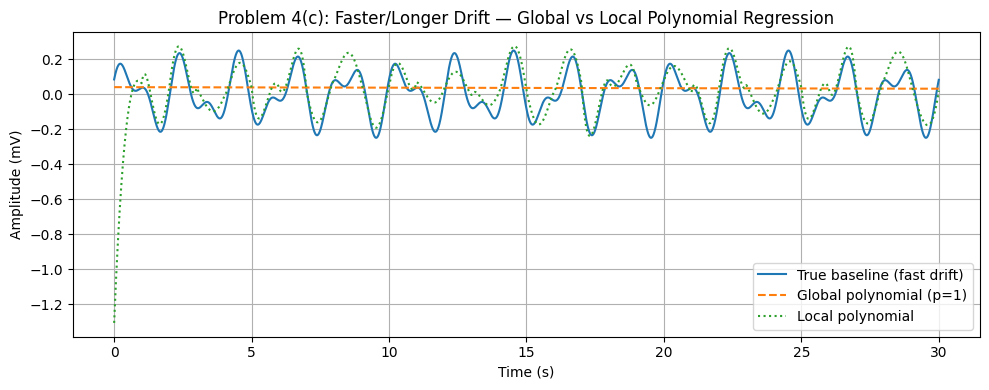

In [16]:
# ============================================================
# Problem 4(c)
# Baseline Estimation under Faster Drift
# ============================================================

plt.figure(
    figsize=(10, 4)
)


plt.plot(
    t_long,
    b_long,
    label="True baseline (fast drift)"
)


plt.plot(
    t_long,
    b_hat_global_long,
    "--",
    label=f"Global polynomial (p={p_star})"
)


plt.plot(
    t_long,
    b_hat_local_long,
    ":",
    label="Local polynomial"
)


plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Amplitude (mV)"
)

plt.title(
    "Problem 4(c): Faster/Longer Drift — "
    "Global vs Local Polynomial Regression"
)

plt.legend()

plt.tight_layout()

plt.show()